# Linear complex intertwiner test

For the linear part of Theorem 9.1, take $F(t,u,\bar u)=K(t)u$, with
$$
K(t)=
\begin{pmatrix}
a(t)+\delta&b(t)e^{-h}&0&0\\
b(t)e^h&c(t)&b(t)e^{-h}&0\\
0&b(t)e^h&c(t)&b(t)e^{-h}\\
0&0&b(t)e^h&a(t)-\delta
\end{pmatrix},
$$
$$
a(t)=\omega+\alpha\cos(\Omega t)+i\gamma,\qquad
c(t)=\omega-\alpha\cos(\Omega t)+i\gamma,\qquad
b(t)=J+\beta\sin(\Omega t)+i\kappa.
$$
All parameters are real. The functional derivatives are
$$
\delta F=K(t)\,\delta u,\qquad F_u=K(t),\qquad F_{\bar u}=0.
$$

Choose the fixed spatial reflection
$$
S=
\begin{pmatrix}
0&0&0&1\\
0&0&1&0\\
0&1&0&0\\
1&0&0&0
\end{pmatrix},
\qquad S^{-1}=S=S^T.
$$
The defect in the linear intertwining condition is
$$
SK(t)^TS^{-1}-K(t)
=-2\delta\,\operatorname{diag}(1,0,0,-1).
$$

| Term | Effect on the conditions |
|---|---|
| Asymmetric hopping $b(t)e^{\pm h}$ | For $h\ne0$ and $b(t)\ne0$, breaks ordinary reciprocity $K^T=K$ but preserves $SK^TS^{-1}=K$. |
| Reflection-symmetric onsite terms $a(t),c(t)$ | Preserve $SK^TS^{-1}=K$ throughout the time schedule. |
| Imaginary coefficients $i\gamma,i\kappa$ | Allow non-Hermitian operators while preserving the intertwining condition. |
| $\delta\,\operatorname{diag}(1,0,0,-1)$ | Breaks the symmetry for this fixed $S$ whenever $\delta\ne0$. |

The valid case has $h\ne0$ and $\delta=0$; the broken case changes only $\delta$.
A nonzero $\delta$ breaks the condition for this fixed $S$ only; the test says nothing about whether some other intertwiner exists.

### Setup
Imports, the 4-site chain size, time grid, and tolerances.
- $S$ is the site-reversal matrix (the intertwiner).
- `upper` is the nearest-neighbour shift used to build the hopping.
- `even_profile` and `odd_profile` are the reflection-symmetric and reflection-antisymmetric on-site patterns. The odd one carries $\delta$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, simpson

N = 4
T = 6.0
Nt = 1001
rtol = 1e-10
atol = 1e-12
t_grid = np.linspace(0.0, T, Nt)

initial_condition_names = [f"Re u0[{j}]" for j in range(N)] + [f"Im u0[{j}]" for j in range(N)]
matrix_parameter_names = ["omega", "alpha", "Omega", "J", "beta", "h", "gamma", "kappa", "delta"]
drive_parameter_names = ["A0", "A3", "omega_f", "phase_f"]
parameter_names = initial_condition_names + matrix_parameter_names + drive_parameter_names

identity = np.eye(N)
S = identity[::-1].copy()
upper = np.diag(np.ones(N - 1), 1)
even_profile = np.diag([1.0, -1.0, -1.0, 1.0])
odd_profile = np.diag([1.0, 0.0, 0.0, -1.0])

q_traj = 0.20
q_T = 0.70
u_target = np.array([0.08 + 0.10j, -0.06 - 0.20j, 0.05j, -0.15 + 0.12j])
np.set_printoptions(precision=6, suppress=False)

### Operator, drive, and their parameter derivatives
$K(t)$ is the on-site part plus $b(t)H(h)$, where $H(h)$ has asymmetric hopping $e^{\mp h}$. That makes $K$ nonreciprocal but keeps $SK^TS^{-1}=K$ when $\delta=0$. The two cases differ only in $\delta$. `dK_dp` and `drive_dp` give the parameter derivatives for the overlap integrals, and the drive has a phase parameter so complex source gradients are tested too.

In [2]:
def make_parameters(delta):
    return np.array(
        [0.65, -0.18, 0.10, 0.05] + [0.12, 0.20, -0.08, 0.15]
        + [0.30, 0.12, 0.90, 0.45, 0.08, 0.35, 0.12, 0.02, delta]
        + [0.08, -0.05, 0.75, 0.40],
        dtype=float,
    )


def unpack(p):
    return dict(zip(parameter_names, p))


def initial_condition(p):
    return np.asarray(p[:N] + 1j * p[N:2*N], dtype=complex)


def hopping(h):
    return np.exp(-h) * upper + np.exp(h) * upper.T


def K(t, p):
    p = unpack(p)
    onsite = (p["omega"] + 1j * p["gamma"]) * identity
    onsite = onsite + p["alpha"] * np.cos(p["Omega"] * t) * even_profile + p["delta"] * odd_profile
    b = p["J"] + p["beta"] * np.sin(p["Omega"] * t) + 1j * p["kappa"]
    return onsite + b * hopping(p["h"])


def dK_dp(t, p, name):
    p = unpack(p)
    ct, st = np.cos(p["Omega"] * t), np.sin(p["Omega"] * t)
    H = hopping(p["h"])
    if name == "omega":
        return identity
    if name == "alpha":
        return ct * even_profile
    if name == "Omega":
        return -p["alpha"] * t * st * even_profile + p["beta"] * t * ct * H
    if name == "J":
        return H
    if name == "beta":
        return st * H
    if name == "h":
        b = p["J"] + p["beta"] * st + 1j * p["kappa"]
        return b * (-np.exp(-p["h"]) * upper + np.exp(p["h"]) * upper.T)
    if name == "gamma":
        return 1j * identity
    if name == "kappa":
        return 1j * H
    if name == "delta":
        return odd_profile
    raise KeyError(name)


def drive(t, p):
    p = unpack(p)
    wt, phase = p["omega_f"] * t, p["phase_f"]
    return np.array([
        p["A0"] * np.exp(1j * phase) * np.sin(wt), 0.0, 0.0,
        p["A3"] * np.exp(-1j * phase) * np.cos(wt),
    ])


def drive_dp(t, p, name):
    pars = unpack(p)
    wt, phase = pars["omega_f"] * t, pars["phase_f"]
    if name == "A0":
        return np.array([np.exp(1j * phase) * np.sin(wt), 0.0, 0.0, 0.0])
    if name == "A3":
        return np.array([0.0, 0.0, 0.0, np.exp(-1j * phase) * np.cos(wt)])
    if name == "omega_f":
        return t * np.array([
            pars["A0"] * np.exp(1j * phase) * np.cos(wt), 0.0, 0.0,
            -pars["A3"] * np.exp(-1j * phase) * np.sin(wt),
        ])
    if name == "phase_f":
        return np.array([1j, 0.0, 0.0, -1j]) * drive(t, p)
    raise KeyError(name)

### Cost and forward solve
`theta_u` and `psi_u` use the standard Wirtinger normalization ($\tfrac12 q\,\overline{(u-r)}$), so the overlap formulas below carry the factor $2\,\mathrm{Re}$. The forward model integrates $\dot u=i(Ku-f)$.

In [3]:
def u_reference(t):
    return np.array([
        0.15 * np.exp(0.30j * t), -0.10j * np.exp(-0.20j * t),
        0.08 * np.exp(-0.15j * t), 0.12j * np.exp(0.25j * t),
    ])


def theta_value(u, t):
    residual = u - u_reference(t)
    return 0.5 * q_traj * np.vdot(residual, residual).real


def theta_u(u, t):
    # Standard Wirtinger normalization; overlap gradients below include 2 Re.
    return 0.5 * q_traj * np.conjugate(u - u_reference(t))


def psi_value(u):
    residual = u - u_target
    return 0.5 * q_T * np.vdot(residual, residual).real


def psi_u(u):
    return 0.5 * q_T * np.conjugate(u - u_target)


def integrate(rhs, initial):
    sol = solve_ivp(
        rhs, (0.0, T), np.asarray(initial, dtype=complex),
        t_eval=t_grid, dense_output=True, method="DOP853", rtol=rtol, atol=atol,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol


def hardware_rhs(t, u, p, applied_drive):
    return 1j * (K(t, p) @ u - applied_drive)


def solve_forward(p):
    return integrate(lambda t, u: hardware_rhs(t, u, p, drive(t, p)), initial_condition(p))


def objective(p):
    forward = solve_forward(p)
    values = [theta_value(forward.y[:, k], t) for k, t in enumerate(t_grid)]
    return simpson(values, x=t_grid) + psi_value(forward.y[:, -1])

### Adjoint solvers, gradient, and diagnostics
`solve_digital_adjoint` integrates the exact $c$-adjoint with $K(T-\tau)^T$.

`solve_physical_adjoint` is the intertwined hardware experiment. The hardware applies $K$, not $K^T$, to the transformed field $d=Sc$:
- it starts from $d(0)=iS\psi_u$;
- it uses drive $-S\theta_u$;
- the result is mapped back with $c=S^{-1}d$.

Passing `intertwiner=identity` gives the plain untransformed run, which assumes ordinary reciprocity.

`operator_defects` reports the reciprocity, intertwining, and Hermiticity defects over the schedule. `taylor_errors` evaluates the cost once per step and reuses it for every gradient being tested.

In [4]:
class DenseSolution:
    def __init__(self, t, y, sol):
        self.t = t
        self.y = y
        self.sol = sol


def solve_digital_adjoint(p, forward):
    c0 = 1j * psi_u(forward.y[:, -1])

    def rhs(tau, c):
        r = T - tau
        return 1j * (K(r, p).T @ c + theta_u(forward.sol(r), r))

    return integrate(rhs, c0)


def solve_physical_adjoint(p, forward, intertwiner=S):
    # One finite-amplitude hardware run: d(0)=i S q_T, drive=-S q.
    # The supplied intertwiner is fixed throughout this experiment.
    d0 = 1j * (intertwiner @ psi_u(forward.y[:, -1]))

    def rhs(tau, d):
        r = T - tau
        source = -intertwiner @ theta_u(forward.sol(r), r)
        return hardware_rhs(r, d, p, source)

    transformed = integrate(rhs, d0)
    # Recover c=S^{-1}d; the hardware operator itself is never transposed.
    recovered = DenseSolution(
        transformed.t, np.linalg.solve(intertwiner, transformed.y),
        lambda tau: np.linalg.solve(intertwiner, transformed.sol(tau)),
    )
    return recovered, transformed


def gradient_from_adjoint(p, forward, adjoint):
    cT = adjoint.sol(T)
    gradient = list(2.0 * cT.imag) + list(2.0 * cT.real)
    c_forward = adjoint.sol(T - t_grid)
    for name in matrix_parameter_names:
        # c^T K_p u = <conj(c), K_p u>_C: no conjugation of c in this dot product.
        values = [
            2.0 * np.real(c_forward[:, k] @ (dK_dp(t, p, name) @ forward.y[:, k]))
            for k, t in enumerate(t_grid)
        ]
        gradient.append(simpson(values, x=t_grid))
    for name in drive_parameter_names:
        values = [
            -2.0 * np.real(c_forward[:, k] @ drive_dp(t, p, name))
            for k, t in enumerate(t_grid)
        ]
        gradient.append(simpson(values, x=t_grid))
    return np.array(gradient, dtype=float)


def relative_field_error(reference, estimate):
    numerator = simpson(np.sum(np.abs(estimate - reference)**2, axis=0), x=t_grid)
    denominator = simpson(np.sum(np.abs(reference)**2, axis=0), x=t_grid)
    return np.sqrt(numerator / denominator)


def operator_defects(p):
    return np.max([
        [
            np.linalg.norm(K(t, p) - K(t, p).T),
            np.linalg.norm(S @ K(t, p).T @ np.linalg.inv(S) - K(t, p)),
            np.linalg.norm(K(t, p) - K(t, p).conj().T),
        ]
        for t in t_grid[::20]
    ], axis=0)


def taylor_errors(p, gradients, h_values, direction):
    chi0 = objective(p)
    p_scale = np.mean(np.abs(p))
    errors = {label: [] for label in gradients}
    for h in h_values:
        delta_p = h * p_scale * direction
        chi_delta = objective(p + delta_p)
        for label, gradient in gradients.items():
            errors[label].append(abs(chi_delta - chi0 - gradient @ delta_p))
    return {label: np.array(values) for label, values in errors.items()}

### Run both cases
Each case computes three gradients: digital, intertwined physical, and untransformed physical. Both cases are nonreciprocal and non-Hermitian; only the valid case has zero intertwining defect. The untransformed run is included in both cases. Its error in the valid case shows that ordinary reciprocity alone is not enough here.

In [5]:
def solve_case(label, delta):
    p = make_parameters(delta)
    forward = solve_forward(p)
    digital = solve_digital_adjoint(p, forward)
    physical, transformed = solve_physical_adjoint(p, forward)
    untransformed, _ = solve_physical_adjoint(p, forward, intertwiner=identity)
    grad_digital = gradient_from_adjoint(p, forward, digital)
    grad_physical = gradient_from_adjoint(p, forward, physical)
    grad_untransformed = gradient_from_adjoint(p, forward, untransformed)
    return {
        "label": label, "p": p, "forward": forward, "digital": digital,
        "physical": physical, "transformed": transformed, "untransformed": untransformed,
        "grad_digital": grad_digital, "grad_physical": grad_physical,
        "grad_untransformed": grad_untransformed, "defects": operator_defects(p),
        "field_error": relative_field_error(digital.y, physical.y),
        "gradient_error": np.linalg.norm(grad_physical - grad_digital) / np.linalg.norm(grad_digital),
        "untransformed_gradient_error": np.linalg.norm(grad_untransformed - grad_digital) / np.linalg.norm(grad_digital),
    }


cases = [
    solve_case("valid intertwiner", delta=0.0),
    solve_case("intertwiner broken", delta=0.18),
]

for result in cases:
    print(result["label"])
    print("  max reciprocity / intertwining / Hermiticity defects:", result["defects"])
    print(f"  relative recovered/digital field error: {result['field_error']:.3e}")
    print(f"  relative recovered/digital gradient error: {result['gradient_error']:.3e}")
    print(f"  relative untransformed/digital gradient error: {result['untransformed_gradient_error']:.3e}")
    print()

valid intertwiner
  max reciprocity / intertwining / Hermiticity defects: [0.927919 0.       1.049302]
  relative recovered/digital field error: 7.048e-16
  relative recovered/digital gradient error: 5.173e-16
  relative untransformed/digital gradient error: 5.031e-01

intertwiner broken
  max reciprocity / intertwining / Hermiticity defects: [0.927919 0.509117 1.049302]
  relative recovered/digital field error: 4.526e-01
  relative recovered/digital gradient error: 4.634e-01
  relative untransformed/digital gradient error: 5.258e-01



### Taylor test of the physical gradients
The intertwined run should give an $h^2$ slope when $\delta=0$ and $h$ when $\delta\neq0$. The untransformed run should give $h$ in both cases.

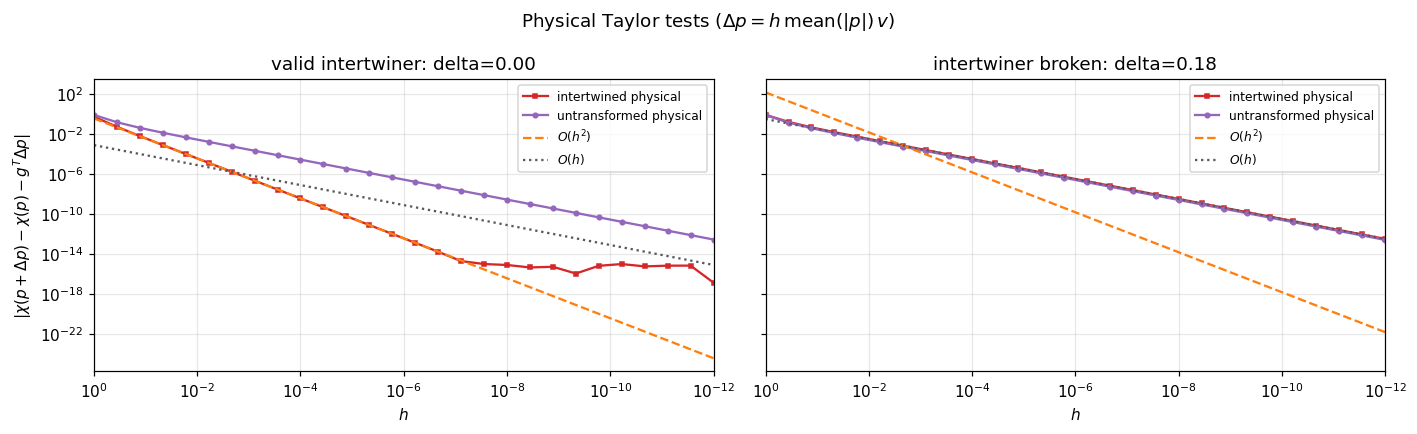

In [6]:
rng = np.random.default_rng(8)
direction = rng.normal(size=len(parameter_names))
direction /= np.linalg.norm(direction)
h_values = np.logspace(0, -12, 28)

# The base-point gradient also includes delta, although a nonzero update to delta
# takes the system outside the family compatible with this fixed S.
for result in cases:
    result["taylor"] = taylor_errors(
        result["p"],
        {
            "intertwined physical": result["grad_physical"],
            "untransformed physical": result["grad_untransformed"],
            "digital adjoint": result["grad_digital"],
        },
        h_values, direction,
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, result in zip(axes, cases):
    errors = result["taylor"]["intertwined physical"]
    anchor = 6
    ax.loglog(h_values, errors, "s-", ms=3, color="tab:red", label="intertwined physical")
    ax.loglog(h_values, result["taylor"]["untransformed physical"],
              "o-", ms=3, color="tab:purple", label="untransformed physical")
    ax.loglog(h_values, errors[anchor] * (h_values / h_values[anchor])**2,
              "--", color="tab:orange", label=r"$O(h^2)$")
    ax.loglog(h_values, errors[anchor] * (h_values / h_values[anchor]),
              ":", color="0.35", label=r"$O(h)$")
    ax.set_xlim(h_values[0], h_values[-1])
    ax.set_title(f"{result['label']}: delta={unpack(result['p'])['delta']:.2f}")
    ax.set_xlabel(r"$h$")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)
axes[0].set_ylabel(r"$|\chi(p+\Delta p)-\chi(p)-g^T\Delta p|$")
fig.suptitle(r"Physical Taylor tests ($\Delta p=h\,\mathrm{mean}(|p|)\,v$)")
plt.tight_layout()
plt.show()

### Control: Taylor test of the digital adjoint
The exact adjoint should give an $h^2$ slope in both cases.

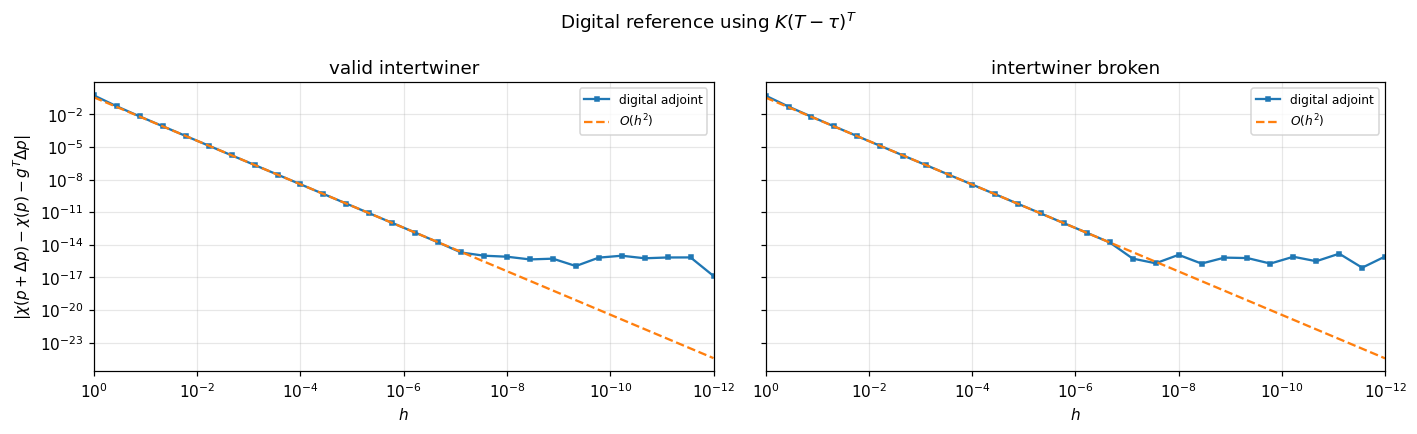

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, result in zip(axes, cases):
    errors = result["taylor"]["digital adjoint"]
    anchor = 6
    ax.loglog(h_values, errors, "s-", ms=3, color="tab:blue", label="digital adjoint")
    ax.loglog(h_values, errors[anchor] * (h_values / h_values[anchor])**2,
              "--", color="tab:orange", label=r"$O(h^2)$")
    ax.set_xlim(h_values[0], h_values[-1])
    ax.set_title(result["label"])
    ax.set_xlabel(r"$h$")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)
axes[0].set_ylabel(r"$|\chi(p+\Delta p)-\chi(p)-g^T\Delta p|$")
fig.suptitle(r"Digital reference using $K(T-\tau)^T$")
plt.tight_layout()
plt.show()

### Automated checks
This cell turns the expectations above into assertions, so a rerun fails loudly if anything drifts:
- $S$ is an involution.
- The intertwining defect equals the analytic $-2\delta\,\mathrm{diag}(1,0,0,-1)$ at every sampled time.
- Both cases are nonreciprocal and non-Hermitian.
- The digital gradient matches central finite differences component by component.
- The fitted Taylor orders are near 2 or 1 as expected.

In [8]:
def finite_difference_gradient(p, step=1e-5):
    gradient = np.empty_like(p)
    for j in range(p.size):
        delta_p = np.zeros_like(p)
        delta_p[j] = step * max(1.0, abs(p[j]))
        gradient[j] = (objective(p + delta_p) - objective(p - delta_p)) / (2.0 * delta_p[j])
    return gradient


def taylor_order(errors):
    mask = (h_values >= 1e-4) & (h_values <= 1e-2)
    return np.polyfit(np.log(h_values[mask]), np.log(errors[mask]), 1)[0]


np.testing.assert_allclose(S @ S, identity, atol=1e-14)
for result in cases:
    p = result["p"]
    # Verify the exact defect across the schedule, not only at a single time.
    for t in t_grid[::20]:
        np.testing.assert_allclose(
            S @ K(t, p).T @ np.linalg.inv(S) - K(t, p),
            -2.0 * unpack(p)["delta"] * odd_profile, atol=1e-14,
        )
    assert result["defects"][0] > 0.1  # Both cases are nonreciprocal.
    assert result["defects"][2] > 0.1  # Both cases are non-Hermitian.
    fd = finite_difference_gradient(p)
    result["grad_finite_difference"] = fd
    np.testing.assert_allclose(result["grad_digital"], fd, rtol=2e-5, atol=2e-7)
    orders = {name: taylor_order(errors) for name, errors in result["taylor"].items()}
    assert 1.8 < orders["digital adjoint"] < 2.2, orders
    assert 0.8 < orders["untransformed physical"] < 1.2, orders
    assert result["untransformed_gradient_error"] > 1e-2
    result["taylor_orders"] = orders
    print(result["label"])
    print(f"  max component digital/finite-difference error: {np.max(np.abs(result['grad_digital'] - fd)):.3e}")
    print("  Taylor orders:", {name: round(value, 3) for name, value in orders.items()})

valid, broken = cases
assert valid["defects"][1] < 1e-12
assert valid["field_error"] < 1e-7
assert valid["gradient_error"] < 1e-7
np.testing.assert_allclose(valid["grad_physical"], valid["grad_finite_difference"], rtol=2e-5, atol=2e-7)
assert 1.8 < valid["taylor_orders"]["intertwined physical"] < 2.2
assert broken["defects"][1] > 0.1
assert broken["field_error"] > 1e-2
assert broken["gradient_error"] > 1e-2
assert 0.8 < broken["taylor_orders"]["intertwined physical"] < 1.2
print("All intertwining, componentwise finite-difference, and Taylor checks passed.")

valid intertwiner
  max component digital/finite-difference error: 1.438e-08
  Taylor orders: {'intertwined physical': np.float64(2.0), 'untransformed physical': np.float64(1.002), 'digital adjoint': np.float64(2.0)}
intertwiner broken
  max component digital/finite-difference error: 1.232e-08
  Taylor orders: {'intertwined physical': np.float64(1.001), 'untransformed physical': np.float64(1.002), 'digital adjoint': np.float64(2.001)}
All intertwining, componentwise finite-difference, and Taylor checks passed.
